In [3]:
# !pip install numpy pandas matplotlib seaborn scikit-learn plotly

In [4]:
import numpy as np
import numpy.linalg as LA
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Загрузка


In [5]:
df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 215 non-null    object 
 1   ssc_percentage         215 non-null    float64
 2   ssc_board              215 non-null    object 
 3   hsc_percentage         215 non-null    float64
 4   hsc_board              215 non-null    object 
 5   hsc_subject            215 non-null    object 
 6   degree_percentage      215 non-null    float64
 7   undergrad_degree       215 non-null    object 
 8   work_experience        215 non-null    object 
 9   emp_test_percentage    215 non-null    float64
 10  specialisation         215 non-null    object 
 11  mba_percent            215 non-null    float64
 12  status                 215 non-null    object 
 13  years_experience       215 non-null    int64  
 14  skills_match_percent   215 non-null    int64  
 15  num_ce

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,2.483721,70.413953,2.423256,0.483721,74.046512
std,10.827205,10.897509,7.358743,13.275956,5.833385,1.701694,17.235065,1.708259,0.500901,14.602447
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000,40.000000,0.000000,0.000000,50.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,1.000000,58.000000,1.000000,0.000000,62.500000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,3.000000,71.000000,3.000000,0.000000,74.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,4.000000,86.000000,4.000000,1.000000,86.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,5.000000,99.000000,5.000000,1.000000,99.000000


In [6]:
from sklearn.preprocessing import OneHotEncoder

object_cols = [t for t in df.select_dtypes(include='object').columns.to_list() if t != 'status']
for col in object_cols:
    cats = np.unique(df[col].values)
    l_enc = OneHotEncoder().fit(cats.reshape(1, -1))
    encoded_names = l_enc.get_feature_names_out(cats)
    for cat, name in zip(cats, encoded_names):
        df[name] = (df[col] == cat).astype(int)

placed = df[df['status'] == 'Placed'].copy()
not_placed = df[df['status'] == 'Not Placed'].copy()
delta = len(placed) - len(not_placed)
df = pd.concat([df, not_placed.sample(n=delta, replace=True)])
target_classes = df.select_dtypes(include='number').columns.to_list()

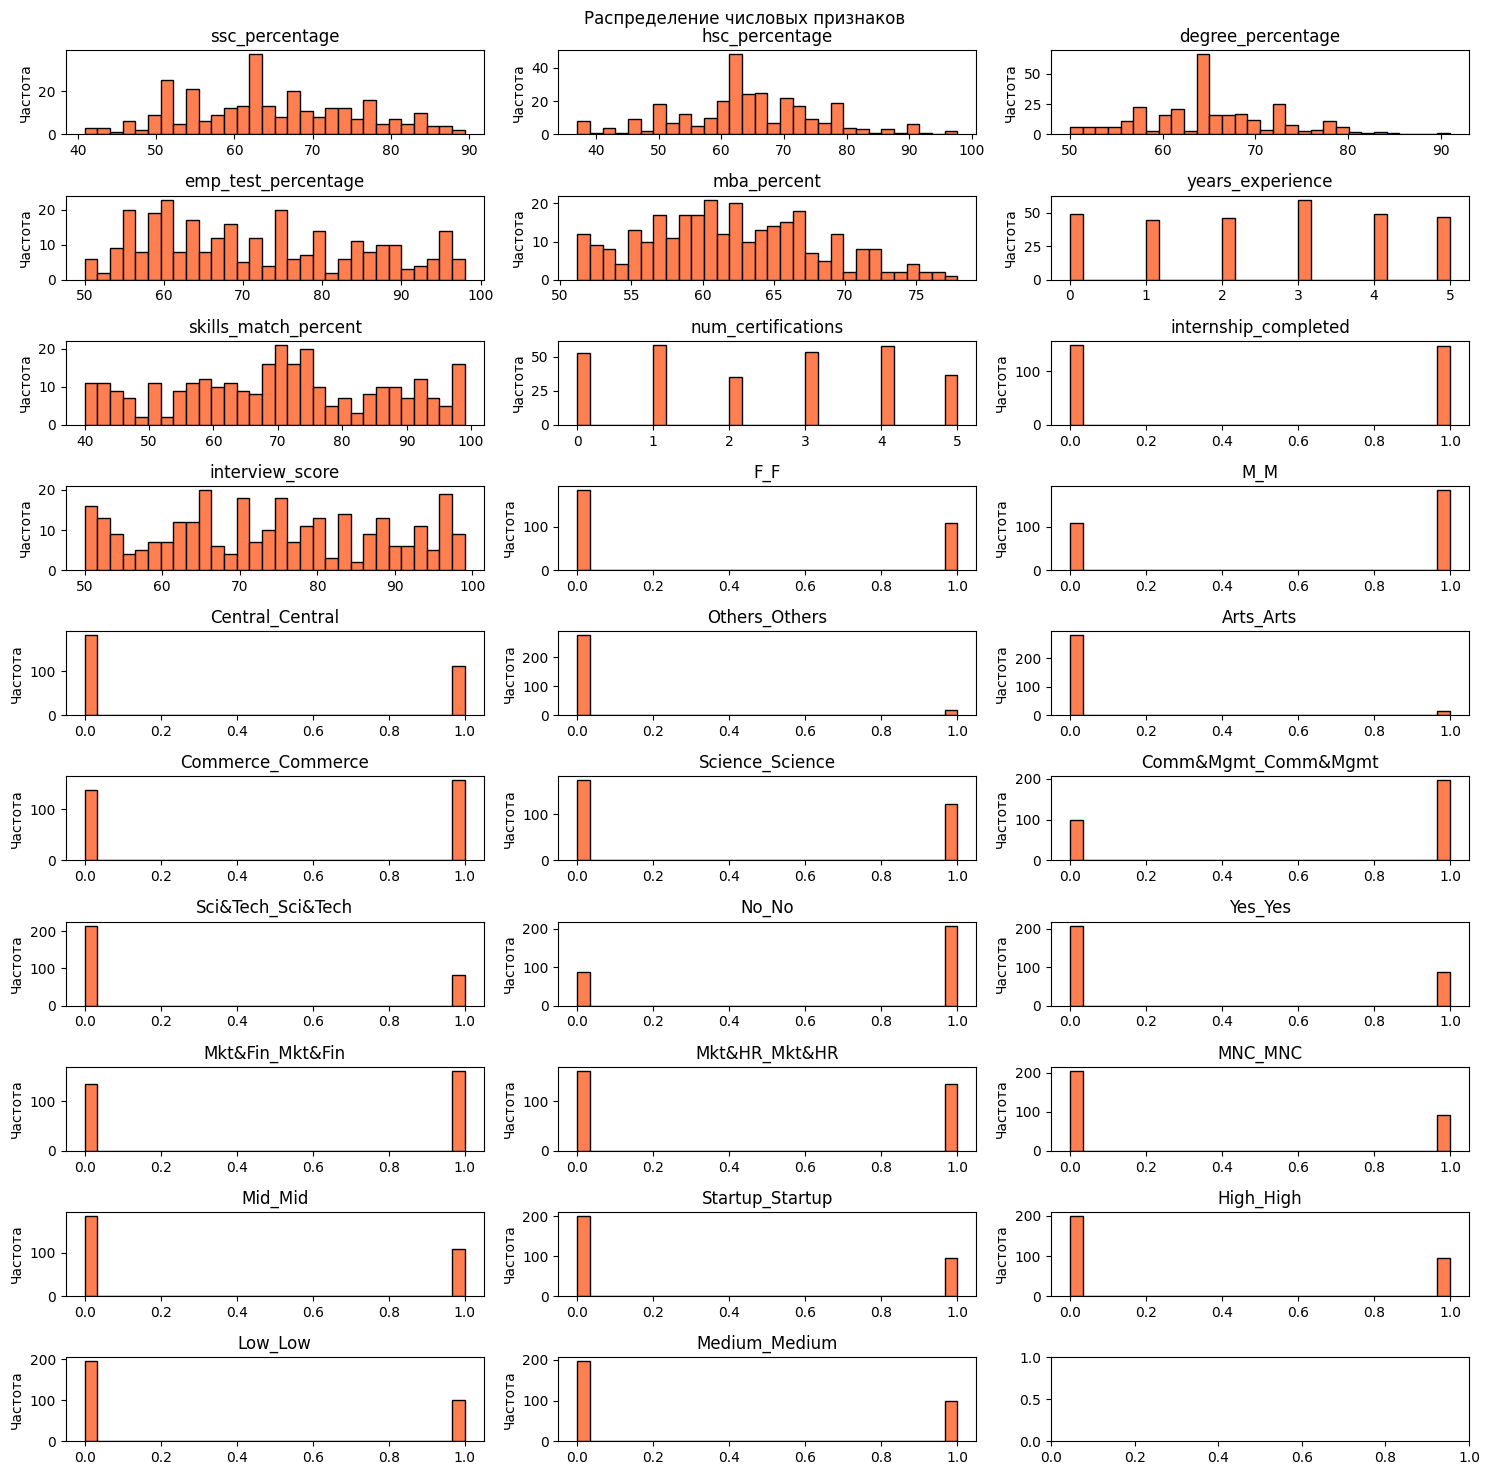

In [7]:
import itertools
# Гистограммы числовых признаков
fig, axes = plt.subplots(len(target_classes) // 3 + 1, 3, figsize=(15, 15))
for ax, col in zip(itertools.chain(*axes), target_classes):
    ax.hist(df[col], bins=30, color='coral', edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Частота')
plt.suptitle('Распределение числовых признаков')
plt.tight_layout()
plt.show()

датасет содержит числовые и категориальные признаки, цена и вес имеют наибольший разброс. Распределения классов примерно равномерны

## 2. Предобработка данных


In [8]:
# Формирование матрицы признаков
feature_cols = target_classes
X = df[feature_cols].values
y = df['status'].values
feature_names = feature_cols

print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (296, 29), y shape: (296,)


In [9]:
# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Mean ~ 0: {X_scaled.mean(axis=0).round(3)}')
print(f'Std  ~ 1: {X_scaled.std(axis=0).round(3)}')

# Транспонируем для SVD: матрица X_svd[признаки x объекты]
X_data = X_scaled.T   # shape: (6, n_samples)
print(f'Матрица данных X_data: {X_data.shape} (m признаков x n объектов)')

Mean ~ 0: [ 0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0. -0.  0.  0.  0.  0. -0.
 -0.  0.  0. -0. -0. -0.  0.  0.  0. -0.  0.]
Std  ~ 1: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Матрица данных X_data: (29, 296) (m признаков x n объектов)


после стандартизации все признаки приведены к единому масштабу

## 3. Сингулярное разложение (SVD)



In [10]:
# Пример SVD на синтетической матрице
np.set_printoptions(precision=2)

A = np.array([[1, 2, 3, 4, 5, 6],
              [2, 3, 4, 5, 6, 7],
              [3, 4, 5, 6, 7, 8],
              [4, 5, 6, 7, 8, 9],
              [5, 6, 7, 8, 9, 10]])

U, S, Vh = LA.svd(A, full_matrices=True)
rank = LA.matrix_rank(A)

print(f'Размер A: {A.shape}')
print(f'Ранг A: {rank}')
print(f'U: {U.shape}, S: {S.shape}, Vh: {Vh.shape}')
print(f'Сингулярные значения: {S}')

# Проверка реконструкции
Sigma = np.zeros(A.shape)
Sigma[:len(S), :len(S)] = np.diag(S)
A_reconstructed = U @ Sigma @ Vh
print(f'Реконструкция точная: {np.allclose(A, A_reconstructed)}')

Размер A: (5, 6)
Ранг A: 2
U: (5, 5), S: (5,), Vh: (6, 6)
Сингулярные значения: [32.4   2.24  0.    0.    0.  ]
Реконструкция точная: True


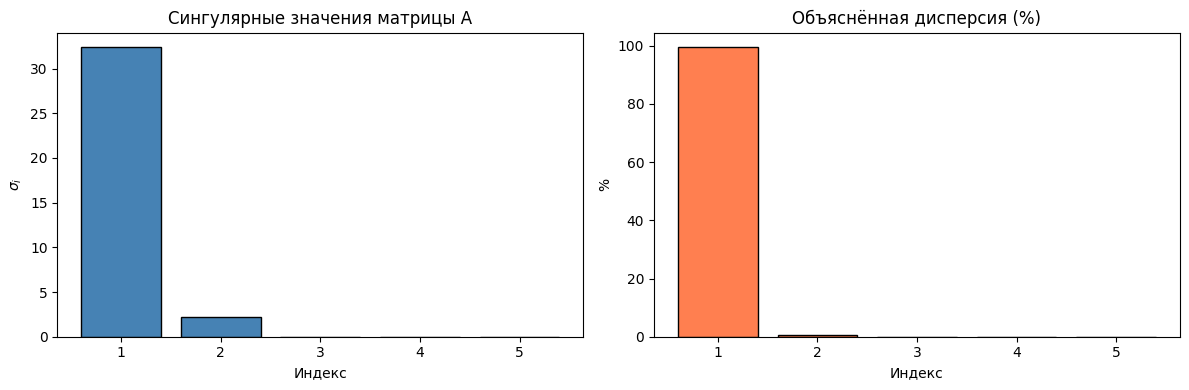

In [11]:
# Визуализация сингулярных значений
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(S)+1), S, color='steelblue', edgecolor='black')
axes[0].set_title('Сингулярные значения матрицы A')
axes[0].set_xlabel('Индекс')
axes[0].set_ylabel('$\sigma_i$')

axes[1].bar(range(1, len(S)+1), S**2 / (S**2).sum() * 100, color='coral', edgecolor='black')
axes[1].set_title('Объяснённая дисперсия (%)')
axes[1].set_xlabel('Индекс')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

первые сингулярные числа значительно больше остальных, данные имеют выраженную низкоранговую структуру. Быстрое убывание сингулярных чисел означает, что несколько компонент описывают большую часть дисперсии

## 4. Четыре фундаментальных подпространства


In [12]:
#четыре фундаментальных подпространства для матрицы A
U, S, Vh = LA.svd(A, full_matrices=True)
rank = LA.matrix_rank(A)  # rank=2

col_space      = U[:, :rank]       
left_null      = U[:, rank:]        
row_space      = Vh[:rank, :].T      
null_space     = Vh[rank:, :].T   

print(f'Пространство столбцов C(X):  размерность {col_space.shape[1]}')
print(f'Левое нулевое N(X^T):        размерность {left_null.shape[1]}')
print(f'Пространство строк R(X):     размерность {row_space.shape[1]}')
print(f'Нулевое пространство N(X):   размерность {null_space.shape[1]}')

#Проверка ортогональности
print(f'C(X) perp N(X^T): {np.allclose(col_space.T @ left_null, 0, atol=1e-10)}')
print(f'R(X) perp N(X):   {np.allclose(row_space.T @ null_space, 0, atol=1e-10)}')

Пространство столбцов C(X):  размерность 2
Левое нулевое N(X^T):        размерность 3
Пространство строк R(X):     размерность 2
Нулевое пространство N(X):   размерность 4
C(X) perp N(X^T): True
R(X) perp N(X):   True


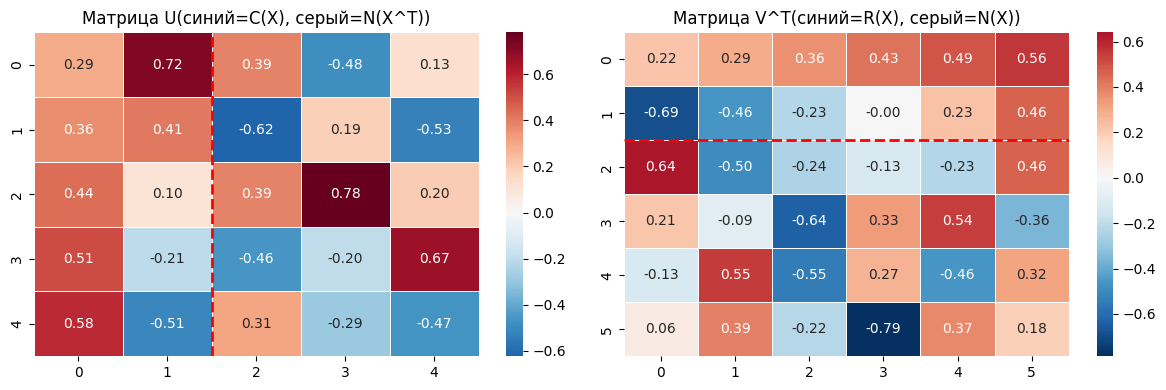

In [13]:
# Визуализация подпространств через тепловую карту
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(U, annot=True, fmt='.2f', ax=axes[0], cmap='RdBu_r', center=0,
            cbar=True, linewidths=0.5)
axes[0].set_title('Матрица U(синий=C(X), серый=N(X^T))')
axes[0].axvline(x=rank, color='red', linewidth=2, linestyle='--')

sns.heatmap(Vh, annot=True, fmt='.2f', ax=axes[1], cmap='RdBu_r', center=0,
            cbar=True, linewidths=0.5)
axes[1].set_title('Матрица V^T(синий=R(X), серый=N(X))')
axes[1].axhline(y=rank, color='red', linewidth=2, linestyle='--')

plt.tight_layout()
plt.show()

 реконструкция матрицы 4x4 из одного слагаемого (ранг 1) сохраняет только главное направление данных, суммирование всех слагаемых точно восстанавливает исходную матрицу

## 5. Теорема Эккарта–Янга 

In [14]:
# Low-rank approximation
U_d, S_d, Vh_d = LA.svd(X_data, full_matrices=False)
m, n = X_data.shape
p = len(S_d)  # ранг

print(f'Матрица данных: {X_data.shape}')
print(f'Сингулярные значения (первые 6): {S_d[:6].round(2)}')

explained = np.cumsum(S_d**2) / np.sum(S_d**2) * 100
for r, e in enumerate(explained[:6], 1):
    print(f'  r={r}: {e:.1f}% дисперсии')

Матрица данных: (29, 296)
Сингулярные значения (первые 6): [33.44 30.41 27.49 24.49 23.56 23.07]
  r=1: 13.0% дисперсии
  r=2: 23.8% дисперсии
  r=3: 32.6% дисперсии
  r=4: 39.6% дисперсии
  r=5: 46.1% дисперсии
  r=6: 52.3% дисперсии


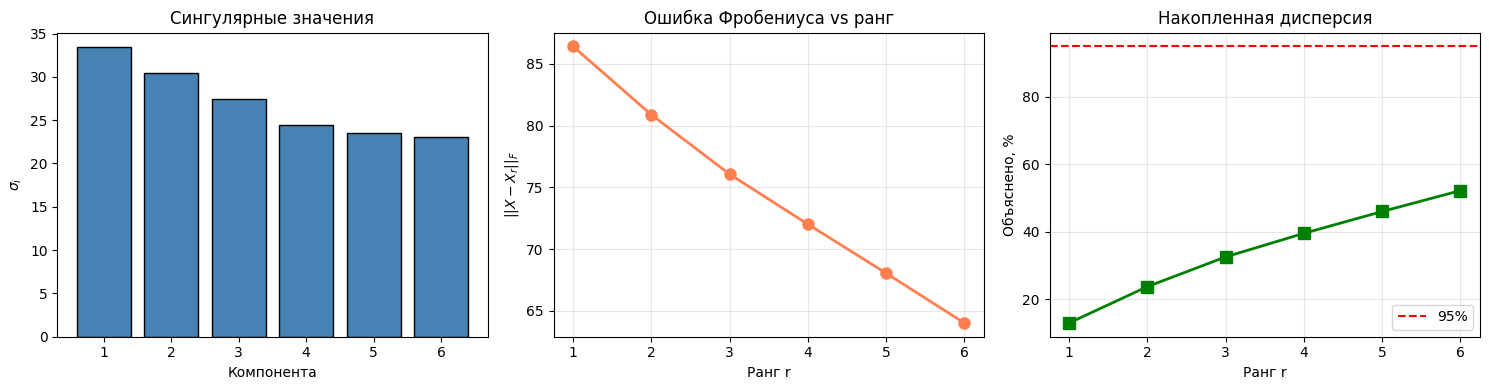

In [15]:
# Приближения разного ранга
ranks = [1, 2, 3, 4, 5, 6]
errors_frob = []
errors_spec = []

for r in ranks:
    X_r = (U_d[:, :r] * S_d[:r]) @ Vh_d[:r, :]
    errors_frob.append(LA.norm(X_data - X_r, 'fro'))
    errors_spec.append(LA.norm(X_data - X_r, 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(ranks, S_d[:6], color='steelblue', edgecolor='black')
axes[0].set_title('Сингулярные значения')
axes[0].set_xlabel('Компонента')
axes[0].set_ylabel('$\sigma_i$')

axes[1].plot(ranks, errors_frob, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].set_title('Ошибка Фробениуса vs ранг')
axes[1].set_xlabel('Ранг r')
axes[1].set_ylabel('$||X - X_r||_F$')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ranks, explained[:6], 's-', color='green', linewidth=2, markersize=8)
axes[2].axhline(y=95, color='red', linestyle='--', label='95%')
axes[2].set_title('Накопленная дисперсия')
axes[2].set_xlabel('Ранг r')
axes[2].set_ylabel('Объяснено, %')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ошибка аппроксимации не очень быстро падает с ростом ранга, необходимо взять почти все признаки

## 6. Полное и уменьшенное SVD

In [16]:
#сравнение полного и уменьшенного SVD
X_test = np.random.rand(5, 2)  # tall-skinny: m=5, n=2

U_full, S_full, V_full   = LA.svd(X_test, full_matrices=True)
U_red,  S_red,  V_red    = LA.svd(X_test, full_matrices=False)

print('Полный SVD')
print(f'U: {U_full.shape}, S: {S_full.shape}, Vh: {V_full.shape}')
print(f'U^T @ U = I: {np.allclose(U_full.T @ U_full, np.eye(5))}')
print(f'U @ U^T = I: {np.allclose(U_full @ U_full.T, np.eye(5))}')

print('Уменьшенный SVD')
print(f'U: {U_red.shape}, S: {S_red.shape}, Vh: {V_red.shape}')
print(f'U_hat^T @ U_hat = I_p: {np.allclose(U_red.T @ U_red, np.eye(2))}')
print(f'U_hat @ U_hat^T = I_m: {np.allclose(U_red @ U_red.T, np.eye(5))}')

Sigma_red = np.diag(S_red)
X_rec = U_red @ Sigma_red @ V_red
print(f'Реконструкция уменьшенным SVD точная: {np.allclose(X_test, X_rec)}')

Полный SVD
U: (5, 5), S: (2,), Vh: (2, 2)
U^T @ U = I: True
U @ U^T = I: True
Уменьшенный SVD
U: (5, 2), S: (2,), Vh: (2, 2)
U_hat^T @ U_hat = I_p: True
U_hat @ U_hat^T = I_m: False
Реконструкция уменьшенным SVD точная: True


полный SVD добавляет к экономному ортонормированный базис нулевого пространства. Для матрицы 5x2 полный U имеет размер 5x5, экономный 5x2

## 7. Полярное разложение

Симметричность S: True
Q ортогональна:   True
Реконструкция X = S @ Q: True


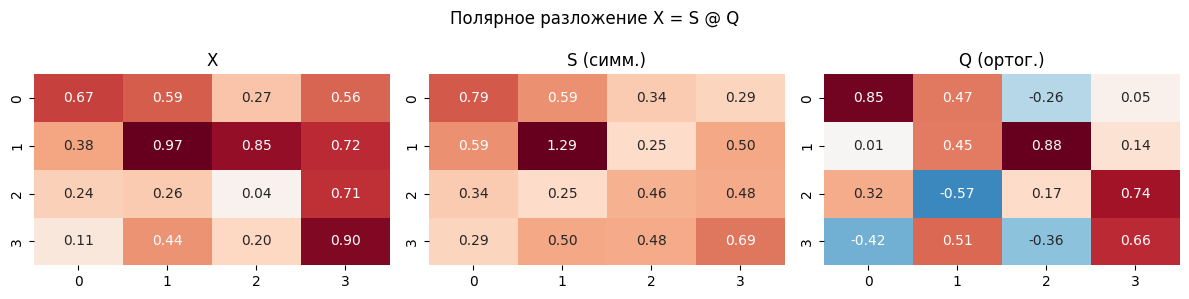

In [17]:
# Полярное разложение
X_sq = np.random.rand(4, 4)
U_p, S_p, Vh_p = LA.svd(X_sq, full_matrices=False)

S_polar = U_p @ np.diag(S_p) @ U_p.T   # симметричная часть
Q_polar = U_p @ Vh_p                     # ортогональная часть

print('Симметричность S:', np.allclose(S_polar, S_polar.T))
print('Q ортогональна:  ', np.allclose(Q_polar @ Q_polar.T, np.eye(4)))
print('Реконструкция X = S @ Q:', np.allclose(X_sq, S_polar @ Q_polar))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, mat, title in zip(axes, [X_sq, S_polar, Q_polar], ['X', 'S (симм.)', 'Q (ортог.)']):
    sns.heatmap(mat, annot=True, fmt='.2f', ax=ax, cmap='RdBu_r', center=0, cbar=False)
    ax.set_title(title)
plt.suptitle('Полярное разложение X = S @ Q')
plt.tight_layout()
plt.show()

полярное разложение X =SQ разделяет преобразование на растяжение (S симметричная положительно полуопределённая) и вращение/отражение (Q ортогональная). Сингулярные числа S совпадают с сингулярными числами X

## 8. Связь SVD и PCA

In [18]:
class DecomAnalysis:

    def __init__(self, X, r_component=None):
        self.X = np.array(X, dtype=float)
        self.r = min(r_component, min(self.X.shape)) if r_component else min(self.X.shape)
        self.rang = LA.matrix_rank(self.X)

    def _positive_diag(self, P): #Знаковая коррекция, диагональ P положительна
        d = np.sign(np.diag(P[:min(P.shape), :min(P.shape)]))
        d[d == 0] = 1
        return np.diag(d)

    def pca(self):#PCA через собственное разложение ковариационной матрицы
        cov = self.X @ self.X.T
        self.eigenvalues, self.P = LA.eigh(cov)
        idx = np.argsort(self.eigenvalues)[::-1]
        self.eigenvalues = self.eigenvalues[idx]
        self.P = self.P[:, idx] @ self._positive_diag(self.P[:, idx])
        self.epsilon = self.P.T @ self.X
        pos_eig = np.maximum(self.eigenvalues, 0)
        esp = np.cumsum(pos_eig) / (np.sum(pos_eig) + 1e-12)
        X_pca = self.P[:, :self.r] @ self.epsilon[:self.r, :]
        return X_pca, esp

    def svd(self):#SVD разложение матрицы данных
        self.U, self.S, self.Vt = LA.svd(self.X, full_matrices=True)
        idx = np.argsort(self.S)[::-1]
        self.S  = self.S[idx]
        self.U  = self.U[:, idx] @ self._positive_diag(self.U[:, idx])
        self.Vt = self.Vt[idx, :]
        Sigma = np.zeros(self.X.shape)
        k = len(self.S)
        Sigma[:k, :k] = np.diag(self.S)
        S2 = self.S**2
        esp = np.cumsum(S2) / (np.sum(S2) + 1e-12)
        X_svd = self.U[:, :self.r] @ Sigma[:self.r, :self.r] @ self.Vt[:self.r, :]
        return X_svd, esp

    def fit(self):
        self.X_pca, self.esp_pca = self.pca()
        self.X_pca_scores = self.epsilon[:self.r, :]
        self.X_svd, self.esp_svd = self.svd()
        self.X_svd_scores = self.U[:, :self.r].T @ self.X

## 9. SVD/PCA


In [19]:
# Применяем DecomAnalysis к датасету
da = DecomAnalysis(X_data, r_component=3)
da.fit()

print('PCA')
print(f'Собственные значения: {da.eigenvalues[:6].round(2)}')
print(f'Объяснённая дисперсия (накоп.): {da.esp_pca[:6].round(3)}')

print('SVD')
print(f'Сингулярные значения: {da.S[:6].round(2)}')
print(f'Объяснённая дисперсия (накоп.): {da.esp_svd[:6].round(3)}')

print('Эквивалентность (lambda == sigma^2):', np.allclose(da.eigenvalues[:len(da.S)], da.S**2, atol=1e-6))

PCA
Собственные значения: [1118.05  924.83  755.5   599.74  555.18  532.33]
Объяснённая дисперсия (накоп.): [0.13 0.24 0.33 0.4  0.46 0.52]
SVD
Сингулярные значения: [33.44 30.41 27.49 24.49 23.56 23.07]
Объяснённая дисперсия (накоп.): [0.13 0.24 0.33 0.4  0.46 0.52]
Эквивалентность (lambda == sigma^2): True


Собственные и сингулярные значения:
  lambda = [1118.05  924.83  755.5   599.74  555.18  532.33  490.14  428.81  373.39
  329.98  318.14  306.92  282.66  257.6   232.43  215.53  193.74  175.29
  163.98  122.82  118.74   88.21    0.     -0.     -0.     -0.     -0.
   -0.     -0.  ]
  sigma^2 = [1118.05  924.83  755.5   599.74  555.18  532.33  490.14  428.81  373.39
  329.98  318.14  306.92  282.66  257.6   232.43  215.53  193.74  175.29
  163.98  122.82  118.74   88.21    0.      0.      0.      0.      0.
    0.      0.  ]


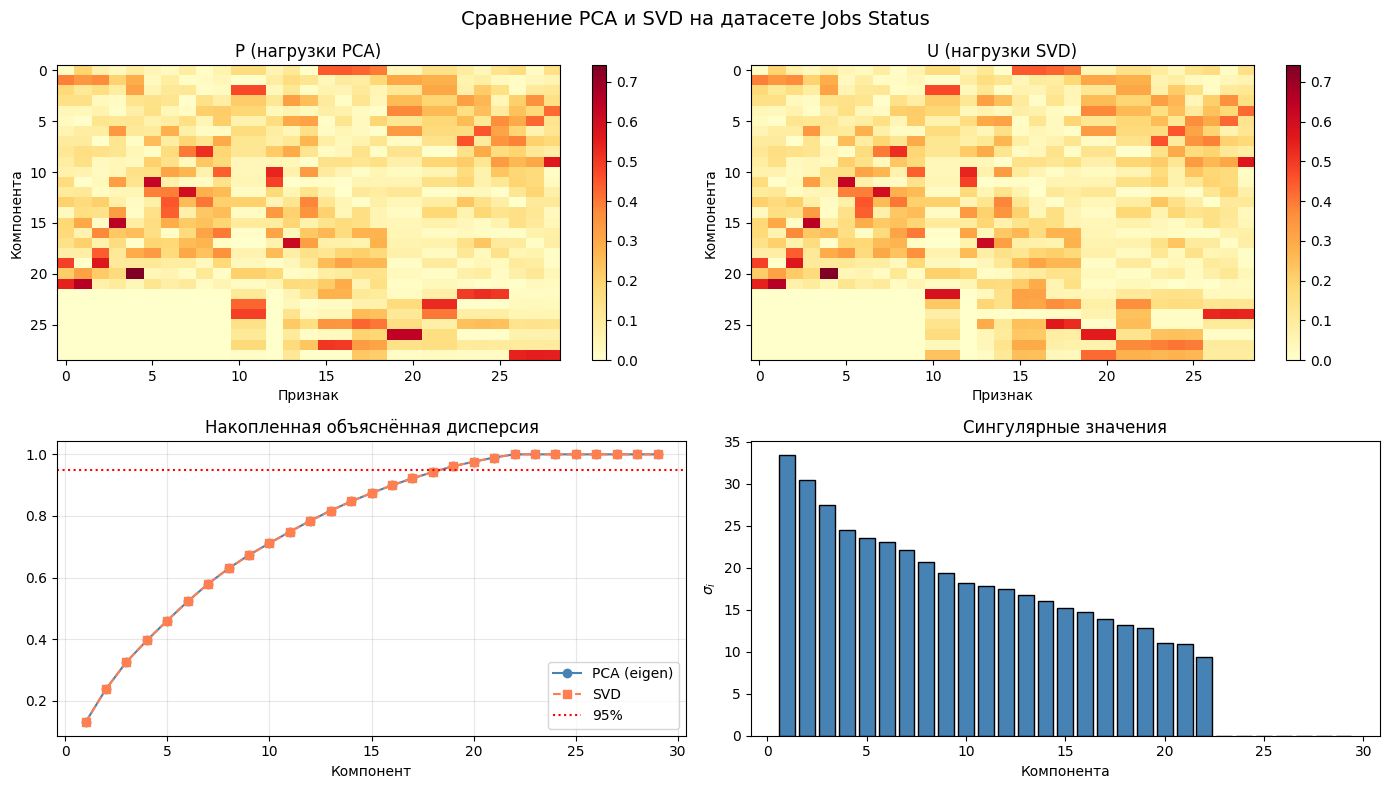

In [20]:
def compare_pca_svd(da):    #Сравнение нагрузок и главных компонент PCA vs SVD
    da.pca(); da.svd()

    print('Собственные и сингулярные значения:')
    print(f'  lambda = {da.eigenvalues.round(2)}')
    print(f'  sigma^2 = {(da.S**2).round(2)}')

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Нагрузки P и U
    for i, (vec, title, ax) in enumerate(zip(
        [da.P.T, da.U.T],
        ['P (нагрузки PCA)', 'U (нагрузки SVD)'],
        axes[0]
    )):
        im = ax.imshow(np.abs(vec), aspect='auto', cmap='YlOrRd')
        ax.set_title(title)
        ax.set_xlabel('Признак')
        ax.set_ylabel('Компонента')
        plt.colorbar(im, ax=ax)

    # Объяснённая дисперсия
    comp = range(1, len(da.eigenvalues)+1)
    axes[1, 0].plot(comp, da.esp_pca, 'o-', label='PCA (eigen)', color='steelblue')
    axes[1, 0].plot(comp, da.esp_svd, 's--', label='SVD', color='coral')
    axes[1, 0].axhline(0.95, color='red', linestyle=':', label='95%')
    axes[1, 0].set_title('Накопленная объяснённая дисперсия')
    axes[1, 0].set_xlabel('Компонент')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Сингулярные значения
    axes[1, 1].bar(comp, da.S, color='steelblue', edgecolor='black')
    axes[1, 1].set_title('Сингулярные значения')
    axes[1, 1].set_xlabel('Компонента')
    axes[1, 1].set_ylabel('$\sigma_i$')

    plt.suptitle('Сравнение PCA и SVD на датасете Jobs Status', fontsize=14)
    plt.tight_layout()
    plt.show()

compare_pca_svd(da)

PCA и SVD дают идентичные результаты проекции (совпадение до знака). DecomAnalysis подтверждает эквивалентность собственные векторы ковариационной матрицы совпадают с правыми сингулярными векторами центрированной X

## 10. Визуализация проекций (2D и 3D)


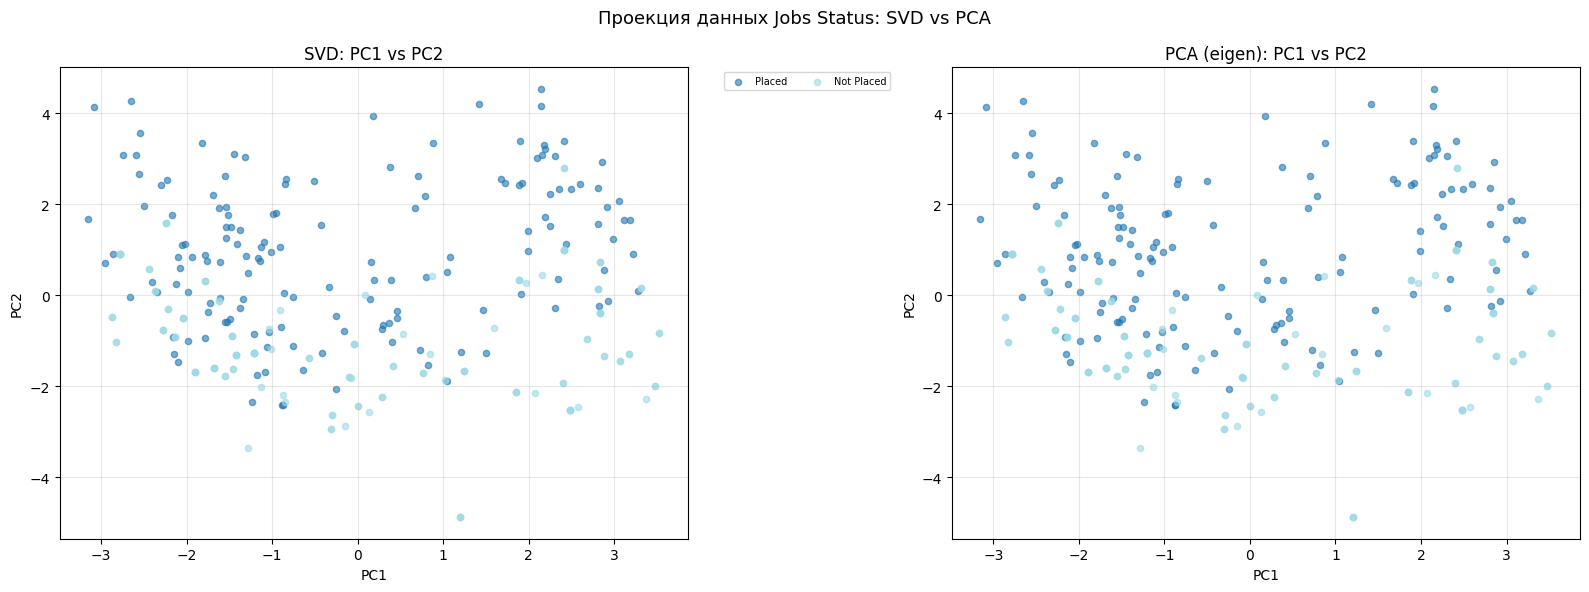

In [21]:
# 2D проекция SVD первые две компоненты
da.fit()
scores_2d = da.X_svd_scores  # shape: (r, n_samples)

target_classes = ['Placed', 'Not Placed']
colors = plt.cm.tab20(np.linspace(0, 1, len(target_classes)))
n_classes = len(target_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls_idx, cls_name in enumerate(target_classes):
    mask = (y == cls_name)
    axes[0].scatter(scores_2d[0, mask], scores_2d[1, mask],
                    label=cls_name, color=colors[cls_idx], alpha=0.6, s=20)

axes[0].set_title('SVD: PC1 vs PC2')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# PCA scores для сравнения
pca_scores = da.X_pca_scores
for cls_idx, cls_name in enumerate(target_classes):
    mask = (y == cls_name)
    axes[1].scatter(pca_scores[0, mask], pca_scores[1, mask],
                    label=cls_name, color=colors[cls_idx], alpha=0.6, s=20)

axes[1].set_title('PCA (eigen): PC1 vs PC2')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Проекция данных Jobs Status: SVD vs PCA', fontsize=13)
plt.tight_layout()
plt.show()

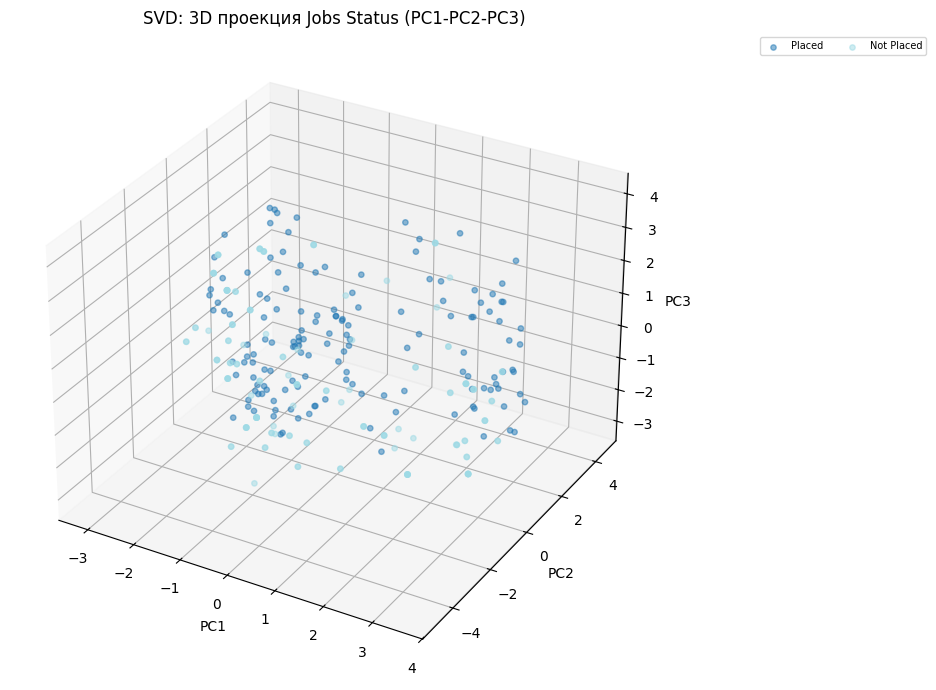

In [22]:
#3D проекция
from mpl_toolkits.mplot3d import Axes3D

da3 = DecomAnalysis(X_data, r_component=3)
da3.fit()
scores_3d = da3.X_svd_scores

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

for cls_idx, cls_name in enumerate(target_classes):
    mask = (y == cls_name)
    ax.scatter(scores_3d[0, mask], scores_3d[1, mask], scores_3d[2, mask],
               label=cls_name, color=colors[cls_idx], alpha=0.5, s=15)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('SVD: 3D проекция Jobs Status (PC1-PC2-PC3)')
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 11. Собственные значения и векторы


Собственные значения XXT (первые 6): [1118.05  924.83  755.5   599.74  555.18  532.33]
sigma^2 из SVD (первые 6):            [1118.05  924.83  755.5   599.74  555.18  532.33]
Совпадают: True


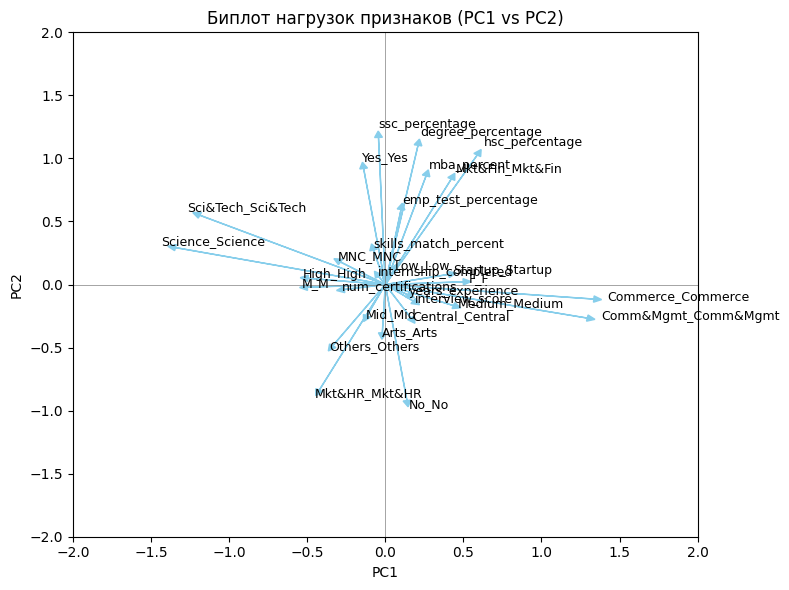

In [27]:
#собственные значения XXT == sigma^2
XXT = X_data @ X_data.T
XTX = X_data.T @ X_data

eig_vals_XXT, eig_vecs_XXT = LA.eigh(XXT)
eig_vals_XXT = eig_vals_XXT[::-1]  # по убыванию

U_svd, S_svd, _ = LA.svd(X_data, full_matrices=False)

print('Собственные значения XXT (первые 6):', eig_vals_XXT[:6].round(2))
print('sigma^2 из SVD (первые 6):           ', (S_svd[:6]**2).round(2))
print('Совпадают:', np.allclose(np.sort(eig_vals_XXT)[::-1][:6], (S_svd[:6]**2), atol=1e-4))

# визуализация биплота нагрузок
fig, ax = plt.subplots(figsize=(8, 6))
for i, feat in enumerate(feature_names):
    ax.arrow(0, 0, U_svd[i, 0]*3, U_svd[i, 1]*3,
             head_width=0.05, head_length=0.05, fc='skyblue', ec='skyblue')
    ax.text(U_svd[i, 0]*3.2, U_svd[i, 1]*3.2, feat, fontsize=9, color='black')

ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.set_title('Биплот нагрузок признаков (PC1 vs PC2)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 12. Псевдообратная матрица

In [24]:
def pseudoinverse(X, tol=1e-10): #Псевдообратная матрица через SVD
    U, S, Vh = LA.svd(X, full_matrices=False)
    S_inv = np.where(S > tol, 1.0 / S, 0.0)
    return Vh.T @ np.diag(S_inv) @ U.T

np.random.seed(42)
X_ols = np.random.rand(100, 4)
beta_true = np.array([1.5, -2.0, 0.5, 3.0])
y_ols = X_ols @ beta_true + np.random.randn(100) * 0.1

X_plus = pseudoinverse(X_ols)
beta_hat = X_plus @ y_ols

print('Истинные beta:    ', beta_true)
print('Оценённые beta:   ', beta_hat.round(3))
print('Ошибка:           ', np.abs(beta_hat - beta_true).round(4))

# Сравнение с np.linalg
beta_np = LA.pinv(X_ols) @ y_ols
print('Совпадает с np.pinv:', np.allclose(beta_hat, beta_np, atol=1e-8))

Истинные beta:     [ 1.5 -2.   0.5  3. ]
Оценённые beta:    [ 1.55 -2.05  0.52  2.98]
Ошибка:            [0.05 0.05 0.02 0.02]
Совпадает с np.pinv: True


In [25]:
X_fat = np.random.rand(3, 10)   # 3 уравнения, 10 неизвестных
y_fat = np.random.rand(3)

X_fat_plus = pseudoinverse(X_fat)
x_minnorm = X_fat_plus @ y_fat

print(f'Решение минимальной нормы: ||x|| = {LA.norm(x_minnorm):.4f}')
print(f'Невязка ||Ax - b||: {LA.norm(X_fat @ x_minnorm - y_fat):.2e}')
print('Точное решение системы: ', np.allclose(X_fat @ x_minnorm, y_fat))

Решение минимальной нормы: ||x|| = 0.9061
Невязка ||Ax - b||: 3.19e-16
Точное решение системы:  True


после демонстрации на tall и fat матрицах видно, что псевдообратная корректно восстанавливает решение МНК при избыточных системах и находит решение минимальной нормы при недоопределённых. SVD делает это устойчиво даже при вырожденных матрицах